# Black Scholes / Autocalls Price Production Audit 01

Validate the first 100 production rows with the four independent engines.

## Load Data And Timings

Load the production audit and display the common four-engine timing view.

,wall seconds,kernel seconds
engine,,
cpp cuda,0.1163,0.1163
pytorch gpu,0.1931,-
cpp cpu,1.228,-
pytorch cpu,7.081,-


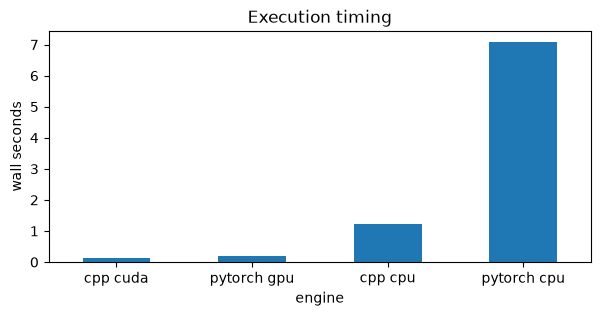

In [1]:
from __future__ import annotations

import json
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import yaml
from IPython.display import display

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "registry").is_dir())
PROJECT_ROOT = ROOT
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / "src_python") not in sys.path:
    sys.path.insert(0, str(ROOT / "src_python"))

from tools.validation.audit import load_production_audit, timing_frame

pd.set_option("display.precision", 4)
audit = load_production_audit(
    ROOT,
    model_family='black_scholes',
    product_family='autocalls',
    delta_crn=False,
)
cpp_gpu = audit.validation["cpp_gpu"].data
python_gpu = audit.validation["python_gpu"].data
cpp_cpu = audit.validation["cpp_cpu"].data
python_cpu = audit.validation["python_cpu"].data
cpp_gpu_spec = audit.validation["cpp_gpu"].specification
cpp_gpu_spec_summary = cpp_gpu_spec["summary"]
production = audit.production.data
production_head = production["results"][:100]
data = {key: document.data for key, document in audit.validation.items()}
specs = {key: document.specification for key, document in audit.validation.items()}
paths = {key: document.json_path for key, document in audit.validation.items()}
spec_paths = {key: document.yaml_path for key, document in audit.validation.items()}
spec_path = spec_paths["cpp_gpu"]
result_path = paths["cpp_gpu"]
PRODUCT_FAMILY = 'autocalls'
performance = timing_frame(audit)
benchmark_row_count = performance.attrs.get("benchmark_row_count")
if benchmark_row_count and benchmark_row_count != 100:
    print(
        f"Performance timing uses one hot call over {benchmark_row_count:,} "
        "benchmark rows; correctness retains the 100-row audit slice."
    )
display(performance.style.format("{:.4g}", na_rep="-"))
ax = performance["wall seconds"].plot(kind="bar", figsize=(7, 3), rot=0)
ax.set_ylabel("wall seconds")
ax.set_title("Execution timing")
plt.show()

## Dataset Coherence

Apply the production, native reproducibility, and statistical checks.

In [2]:
from tools.validation.audit import coherence_frame

coherence = coherence_frame(audit)
display(
    coherence.style.format(
        {
            "max abs error": "{:.3e}",
            "max rel error (%)": "{:.3f}",
            "max z-score": "{:.3f}",
        },
        na_rep="-",
    )
)

,output,max abs error,max rel error (%),relative rows,max z-score
check,,,,,
production stored cpp cuda vs regenerated cpp cuda,price,0.000e+00,0.000,100,0.000
cpp cpu vs cpp cuda,price,3.735e-13,0.000,100,0.000
pytorch cpu vs pytorch gpu,price,8.227e-03,1.026,100,2.804
cpp cuda vs pytorch gpu,price,5.803e-03,0.684,100,2.669


## Path Reconstruction Check

Reconstruct the exact Philox paths for one production row and reprice it.

In [3]:
from tools.paths.black_scholes import load_result_context, reconstruct_paths_from_context
from tools.registry.result.common.autocalls import price_from_paths

row_id = "000001"
result_row, model, product, _ = load_result_context(
    result_json_path=paths["cpp_gpu"],
    result_yaml_path=spec_path,
    row_id=row_id,
)
num_paths = int(cpp_gpu_spec["summary"]["num_paths"])
num_steps = int(round(float(product["maturity"]) * 52))
paths_matrix, path_kernel_seconds = reconstruct_paths_from_context(
    result_row=result_row,
    model=model,
    product=product,
    num_paths=num_paths,
    num_steps=num_steps,
    use_gpu=True,
)
repriced = price_from_paths(paths_matrix, model=model, product=product)
stored = next(row for row in cpp_gpu["results"] if row["id"] == row_id)["outputs"]
display(pd.DataFrame([
    {"quantity": "stored price", "value": stored["price"]},
    {"quantity": "repriced from reconstructed paths", "value": repriced["price"]},
    {"quantity": "absolute error", "value": abs(stored["price"] - repriced["price"])},
    {"quantity": "path kernel seconds", "value": path_kernel_seconds},
]))

,quantity,value
0,stored price,8.3927e-01
1,repriced from reconstructed paths,8.3927e-01
2,absolute error,2.5535e-14
3,path kernel seconds,2.8988e-03


## Regeneration Commands

The commands below rebuild the native library and regenerate this audit chain.

```bash
cmake -S src_cpp -B /tmp/ai_factory_cpp_build -DCMAKE_BUILD_TYPE=Release
cmake --build /tmp/ai_factory_cpp_build --target ai_factory_cuda_shared -j
python registry/production/models/black_scholes/generators/black_scholes_01.py
python registry/production/products/autocalls/generators/autocalls_01.py
python registry/production/results/black_scholes/autocalls/generators/black_scholes_01__autocalls_01__cpp_gpu_philox_01.py
python registry/validation/models/black_scholes/generators/black_scholes_01__first_100.py
python registry/validation/products/autocalls/generators/autocalls_01__first_100.py
python registry/validation/results/black_scholes/autocalls/generators/black_scholes_01__first_100__autocalls_01__first_100__cpp_gpu_philox_01.py
python registry/validation/results/black_scholes/autocalls/generators/black_scholes_01__first_100__autocalls_01__first_100__cpp_cpu_philox_01.py
python registry/validation/results/black_scholes/autocalls/generators/black_scholes_01__first_100__autocalls_01__first_100__python_gpu_pytorch_01.py
python registry/validation/results/black_scholes/autocalls/generators/black_scholes_01__first_100__autocalls_01__first_100__python_cpu_pytorch_01.py
```